In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

100%|██████████| 170M/170M [00:02<00:00, 70.8MB/s]


In [4]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, 3)
        self.bn1 = nn.BatchNorm2d(16)

        self.pool = nn.MaxPool2d(2,2)

        self.conv2 = nn.Conv2d(16, 32, 3)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, 3)
        self.bn3 = nn.BatchNorm2d(64)

        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(64*2*2, 120)
        self.fc2 = nn.Linear(120, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))

        x = x.view(-1, 64*2*2)

        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [5]:
def train_model(batch_size, lr, epochs=10):
    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
    testloader = DataLoader(testset, batch_size=batch_size, shuffle=False)

    model = CNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_losses, test_losses, test_accuracies = [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        loop = tqdm(trainloader, desc=f"BS={batch_size}, LR={lr}, Epoch={epoch+1}")

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        train_losses.append(running_loss / len(trainloader))

        # Evaluation
        model.eval()
        correct, total = 0, 0
        test_loss = 0.0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        test_accuracies.append(acc)

        test_losses.append(test_loss / len(testloader))

        print(f"Epoch {epoch+1}: Test Accuracy = {acc:.2f}%")

    return model, train_losses, test_losses, test_accuracies

In [6]:
batch_sizes = [16, 32, 64]
learning_rates = [0.1, 0.01, 0.001]

results = {}

for bs in batch_sizes:
    for lr in learning_rates:
        print(f"\nRunning with BatchSize={bs}, LearningRate={lr}")

        model, train_losses, test_losses, accs = train_model(bs, lr, epochs=7)

        results[(bs, lr)] = {
            "train_loss": train_losses,
            "test_loss": test_losses,
            "accuracy": accs
        }


Running with BatchSize=16, LearningRate=0.1


BS=16, LR=0.1, Epoch=1: 100%|██████████| 3125/3125 [01:11<00:00, 43.85it/s, loss=1.13]


Epoch 1: Test Accuracy = 55.09%


BS=16, LR=0.1, Epoch=2: 100%|██████████| 3125/3125 [01:09<00:00, 44.68it/s, loss=1.11]


Epoch 2: Test Accuracy = 60.88%


...

Epoch 5: Test Accuracy = 41.52%


BS=64, LR=0.001, Epoch=6: 100%|██████████| 782/782 [00:53<00:00, 14.69it/s, loss=1.36]


Epoch 6: Test Accuracy = 42.75%


BS=64, LR=0.001, Epoch=7: 100%|██████████| 782/782 [00:53<00:00, 14.73it/s, loss=1.55]


Epoch 7: Test Accuracy = 44.07%


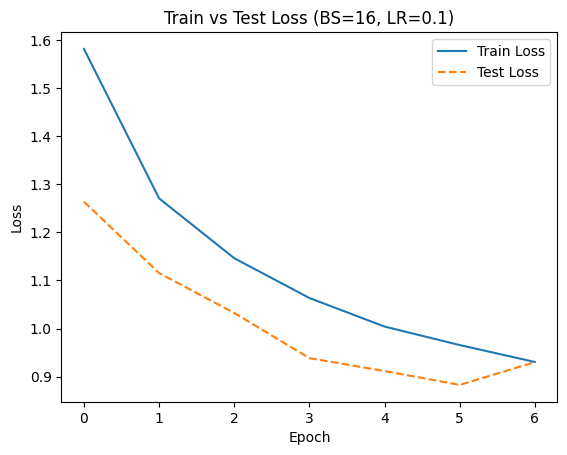

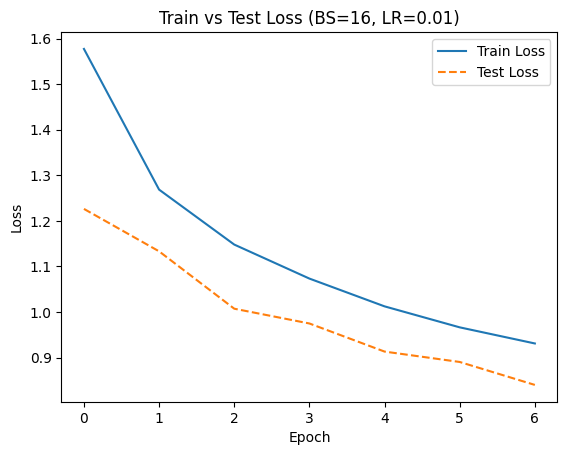

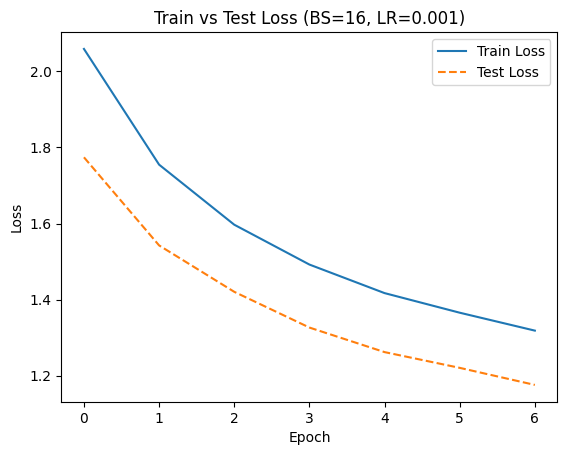

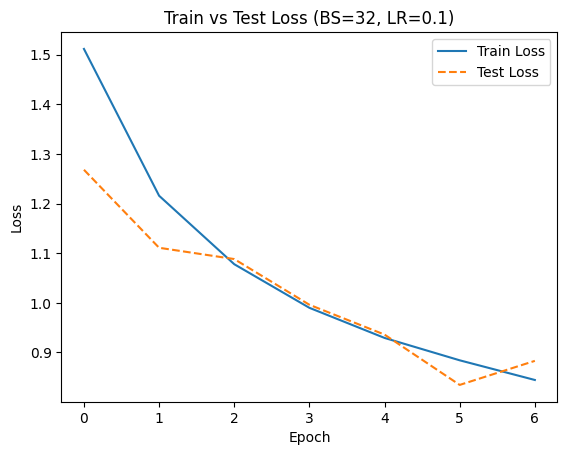

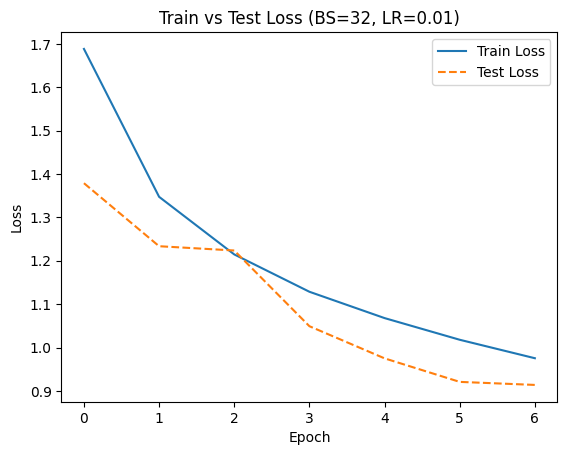

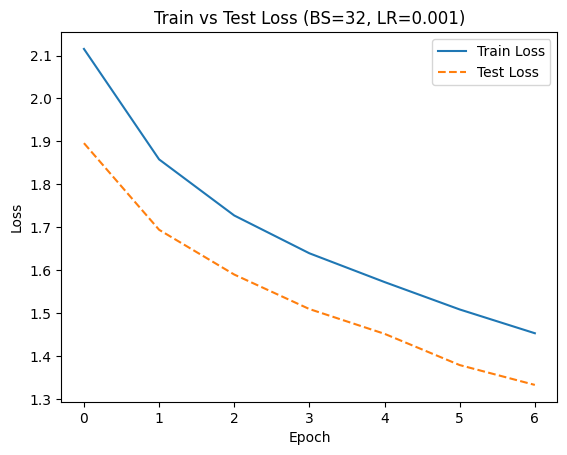

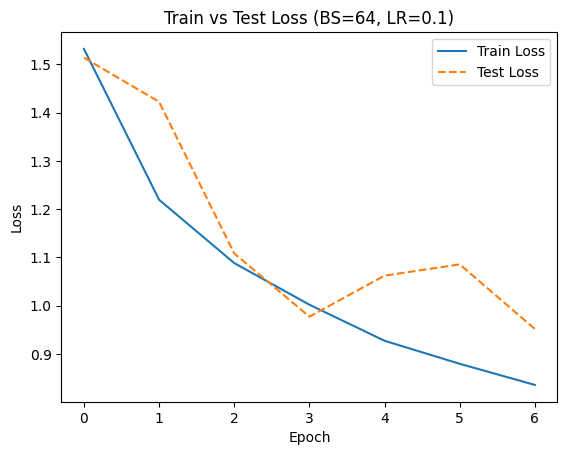

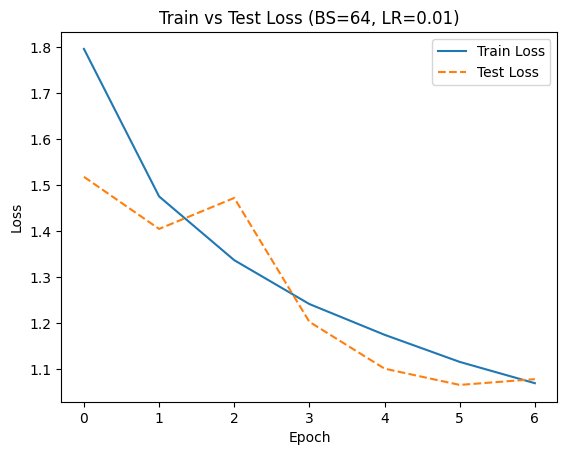

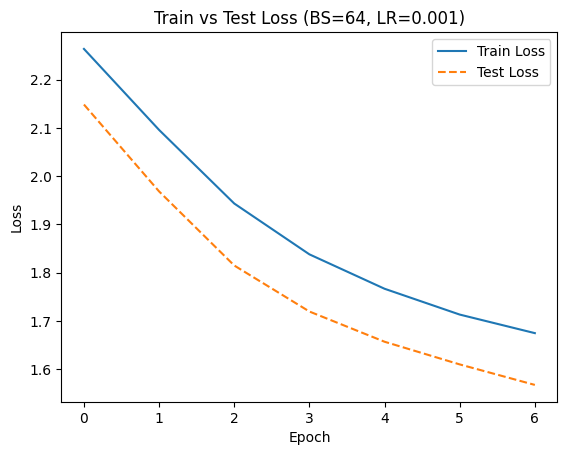

In [7]:
for (bs, lr), res in results.items():
    plt.figure()  # Create a new figure for each combination

    plt.plot(res["train_loss"], label=f"Train Loss")
    plt.plot(res["test_loss"], linestyle='--', label=f"Test Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Test Loss (BS={bs}, LR={lr})")
    plt.legend()

    plt.show()